In [6]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [7]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_df_path = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_score""","""pink""","""GPN-MSA""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#00838F""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#26C6DA""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""abexp_abs_max""","""#80CBC4""","""AbExp abs max""",1


In [8]:
# new_anno_df_path = '/home/dnanexus/data_dir/flashzoi_proximal_variants_gencode40_avg_score.parquet'

# new_anno_df = (
#     pl.read_parquet(new_anno_df_path)
#     .with_columns(
#         fz_blood = (pl.col('RNA:blood_7531') + pl.col('RNA:blood_7532') + pl.col('RNA:blood_7533'))/3
#     )
#     .with_columns(
#         max_fz_blood = pl.col('fz_blood').abs()
#     )
#     .select(['id', 'region', 'fz_blood', 'max_fz_blood'])
#     .lazy()
# )

# new_anno_df.head().collect()

In [9]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_df_path is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
fillna_cols = [c+'_is_na' for c in existing_annos]

anno = (
    anno
    # .with_columns(
    #     encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
    #     encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    # )
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        (pl.any_horizontal(cs.contains("consequence_splice") == True)) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose pLoF variants
        # (pl.col('loftee_hc') == True) &

        # Choose protein domain
        # (pl.col('ted_domain') == True) &
        # (pl.col('mobi_curated_disorder_priority') == True) &
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('low_complexity_domain') == True) &

        # Choose regulatory region
        # (pl.col('not_in_encode') == False) &
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &

        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

Error: path "/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


id,region,verphylop,tss,absplice_dna_max,relative_cds_position,gene_length,gpn_score,esmscoremissense,gene_name,dist_to_tss,am_pathogenicity,absplice2_max,abexp_abs_max,strand,pangolin_score,score_pai3d,promoterai,delta_score,cadd_raw
str,str,f32,i64,f32,f32,i64,f32,f32,str,i64,f32,f32,f32,cat,f32,f32,f32,f32,f32
"""chr8:6519856:T:C""","""ENSG00000091879""",-3.161,6563409,0.003,0.0,63779,-1.15,0.0,"""ANGPT2""",43553,0.0,0.000247,0.038051,"""-""",0.0,0.0,0.0,0.0,-1.267125
"""chr2:73455162:C:G""","""ENSG00000116127""",4.069,73385757,0.007,0.6,239410,-8.47,-4.235,"""ALMS1""",69405,0.3752,0.009521,0.067689,"""+""",0.0,0.0,0.0,0.0,4.401463
"""chr15:48797734:G:A""","""ENSG00000103995""",0.487,48811146,0.003,0.0,98220,-1.32,0.0,"""CEP152""",13412,0.0,0.001272,0.01748,"""-""",0.07,0.0,0.0,0.05,0.971192
"""chr9:137021883:G:A""","""ENSG00000107331""",-1.042,137028915,0.004,0.0,21683,-0.38,0.0,"""ABCA2""",7032,0.0,0.003368,0.013932,"""-""",0.04,0.0,0.0,0.05,0.003432
"""chr2:88558996:T:G""","""ENSG00000172071""",0.221,88691518,0.003,0.0,134779,-4.37,0.0,"""EIF2AK3""",132522,0.0,0.000371,0.016585,"""-""",0.0,0.0,0.0,0.0,0.451308
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr4:40102066:G:T""","""ENSG00000078177""",0.359,40056849,0.01,0.0,101404,-0.61,0.0,"""N4BP2""",45217,0.0,0.000361,0.012333,"""+""",0.0,0.0,0.0,0.0,1.100489
"""chr4:7682894:G:C""","""ENSG00000184985""",6.227,7192537,0.307,0.0,550300,-12.2,0.0,"""SORCS2""",490357,0.0,0.283584,0.387772,"""+""",0.76,0.0,0.0,0.93,2.783093
"""chr19:35849162:A:C""","""ENSG00000161270""",-0.186,35869287,0.005,0.0,43917,-1.51,0.0,"""NPHS1""",20125,0.0,0.009516,0.094489,"""-""",0.17,0.0,0.0,0.17,1.698173


In [10]:
anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == False
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

id,region,annotation,annotation_is_na
str,str,str,i8
"""chr8:6519856:T:C""","""ENSG00000091879""","""pangolin_score""",0
"""chr2:73455162:C:G""","""ENSG00000116127""","""pangolin_score""",0
"""chr15:48797734:G:A""","""ENSG00000103995""","""pangolin_score""",0
"""chr9:137021883:G:A""","""ENSG00000107331""","""pangolin_score""",0
"""chr2:88558996:T:G""","""ENSG00000172071""","""pangolin_score""",0


In [ ]:
# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'regulatory_nondir'] # CDS
# selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
# selected_categories = ['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region', 'gene_name']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region", "gene_name"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    # Keep variants that don't have fillna annotation
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='semi'
    )

    .collect(engine='streaming')
)

melted_anno

id,region,gene_name,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,str,f32,str,i8,f32
"""chr19:50724607:T:G""","""ENSG00000105472""","""CLEC11A""","""absplice_dna_max""",0.01,"""splicing""",1,88298.0
"""chr12:131105869:A:T""","""ENSG00000111452""","""ADGRD1""","""absplice_dna_max""",0.194,"""splicing""",1,31669.0
"""chr1:107574041:A:C""","""ENSG00000134215""","""VAV3""","""absplice_dna_max""",0.011,"""splicing""",1,83415.0
"""chr19:3203749:C:G""","""ENSG00000125912""","""NCLN""","""absplice_dna_max""",0.027482,"""splicing""",1,62705.0
"""chr1:55007270:C:G""","""ENSG00000162399""","""BSND""","""absplice_dna_max""",0.003,"""splicing""",1,261268.0
…,…,…,…,…,…,…,…
"""chr18:49569556:C:T""","""ENSG00000101670""","""LIPG""","""delta_score""",0.0,"""splicing""",1,287817.0
"""chr14:67642172:T:C""","""ENSG00000081181""","""ARG2""","""delta_score""",0.0,"""splicing""",1,287817.0
"""chr13:33110921:T:C""","""ENSG00000133121""","""STARD13""","""delta_score""",0.0,"""splicing""",1,287817.0


In [12]:
anno['gene_name'].value_counts(sort=True)

gene_name,count
str,u64
"""TTN""",2130
"""NEB""",958
"""OBSCN""",941
"""SYNE1""",906
"""HMCN2""",766
…,…
"""CFC1""",1
"""HS3ST3B1""",1
"""NEUROD1""",1


In [13]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [14]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000167941""","""heel_bone_mineral_density_bmd_…",0.004143,0.309961,0.309961,1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
…,…,…,…,…,…
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0
"""ENSG00000114796""","""position_of_pulse_wave_notch_i…",0.03963,-0.003476,0.003476,-1.0


## Odds ratio computation

In [15]:
n_steps = 101
min_rank_cutoff = 1_000
max_rank_cutoff = 10_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
1000
1058
1119
1185
1254
…
229483
242852
257000


In [16]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('loftee_corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    # .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_ptile", "mean_pheno_value_dircor_ptile"])
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_rank_desc", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,i64,u64,u64,u64,u64,f64
"""pangolin_score""","""ENSG00000058600""","""POLR3E""","""forced_vital_capacity_fvc_int""",287817,126,0,0,0,NaN
"""verphylop""","""ENSG00000182752""","""PAPPA""","""sitting_height_int""",287817,55,56,0,0,NaN
"""absplice_dna_max""","""ENSG00000058600""","""POLR3E""","""forced_vital_capacity_fvc_int""",287817,126,0,0,0,NaN
"""absplice2_max""","""ENSG00000005844""","""ITGAL""","""lymphocyte_count_int""",287817,0,181,0,0,NaN
"""absplice2_max""","""ENSG00000084774""","""CAD""","""mean_reticulocyte_volume_int""",287817,0,275,0,0,NaN
…,…,…,…,…,…,…,…,…,…
"""cadd_raw""","""ENSG00000080200""","""CRYBG3""","""shbg_int""",1000,0,0,12,86,NaN
"""pangolin_score""","""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",1000,0,0,0,230,NaN
"""absplice_dna_max""","""ENSG00000185559""","""DLK1""","""standing_height_int""",1000,0,0,25,0,NaN


In [17]:
or_df['annotation'].unique()

annotation
str
"""verphylop"""
"""absplice2_max"""
"""absplice_dna_max"""
"""cadd_raw"""
"""gpn_score"""
"""delta_score"""
"""pangolin_score"""


## Plotting

In [18]:
print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 20) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""gpn_score""",3.0,1000,-3.0,43,0.0,3.482265,1.242155,5.916889,1.047641,"""pink""","""GPN-MSA""","""conservation"""
"""cadd_raw""",3.0,1000,-3.0,44,0.0,0.923143,0.329395,1.568757,0.277528,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""verphylop""",3.0,1000,-3.0,38,0.0,1.183094,0.292168,1.755742,0.610445,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",3.024486,1058,-3.024486,38,0.0,1.264102,0.295745,1.843763,0.684442,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""cadd_raw""",3.024486,1058,-3.024486,48,0.0,0.948326,0.317805,1.571225,0.325428,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""cadd_raw""",5.434524,271972,-5.434524,155,0.895522,1.240927,0.101829,1.440513,1.041341,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""verphylop""",5.434524,271972,-5.434524,151,0.95122,1.196426,0.108492,1.40907,0.983782,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""pangolin_score""",5.434524,271972,-5.434524,237,1.21875,1.528191,0.078862,1.682761,1.373622,"""#2E7D32""","""Pangolin""","""splicing"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


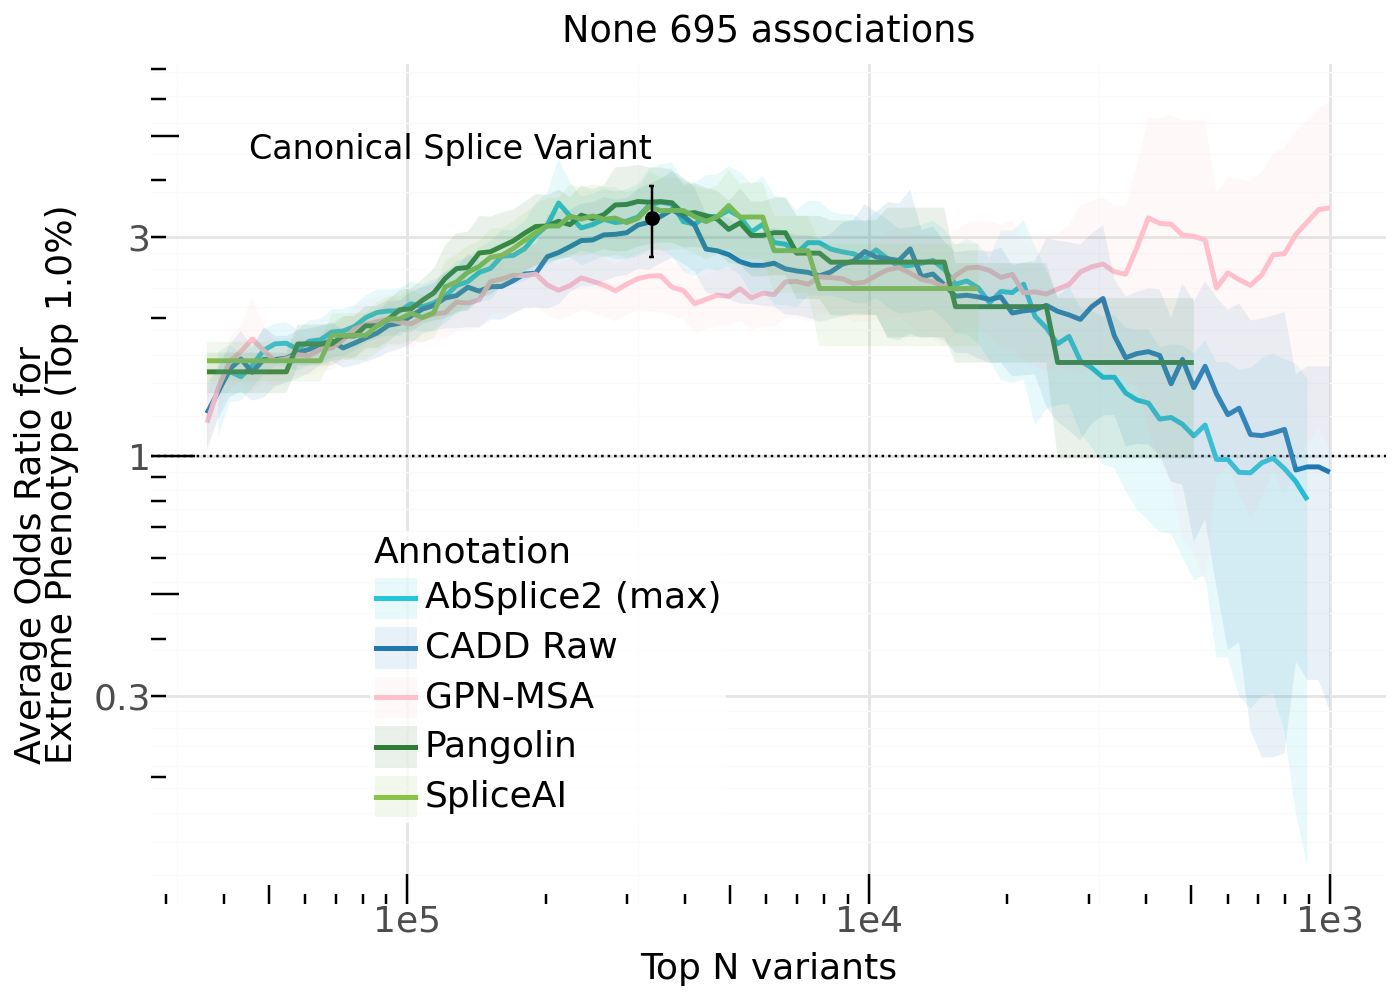

In [23]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') <= -4) &

        # (pl.col('annotation').is_in(['am_pathogenicity', 'score_pai3d', 'esmscoremissense']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'cadd_raw', 'abexp_abs_max']))
        (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'pangolin_score', 'delta_score', 'absplice2_max']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)


or_points = pl.DataFrame({
    'annotation': ['loftee_hc', 'loftee_hc', 'canonical_splice_variant'],
    'region': ['gene_body', 'cds', 'all_vep_splice_regions'],
    'n_vars': [-np.log10(131_682), -np.log10(131_682), -np.log10(29_524)],
    'mean_or': [4.291864, 3.707762, 3.304879],
    'se_or': [0.192267, 0.130931, 0.297136],
}).with_columns(
    ci_low_pheno = pl.col('mean_or') - 1.96 * pl.col('se_or'),
    ci_high_pheno = pl.col('mean_or') + 1.96 * pl.col('se_or'),
)

annotation = 'canonical_splice_variant' #'loftee_hc'
loftee_cat = 'all_vep_splice_regions' #'gene_body'

loftee_point  = [
    geom_point(
        or_points.filter(pl.col('region')==loftee_cat), 
        aes(x='n_vars', y='mean_or'),
        color='black',
        size=2
    ),
    geom_errorbar(
        or_points.filter(pl.col('region')==loftee_cat),
        aes(x='n_vars', y='mean_or', ymin='ci_low_pheno', ymax='ci_high_pheno'),
        width=0.01,
    ),
    geom_text(
        or_points.filter(pl.col('region')==loftee_cat),
        aes(x='n_vars', y='mean_or', label='"Canonical Splice Variant"'),
        # nudge_x=-0.1,
        nudge_y=0.15,
        size=12,
        ha='right'
    )
]

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + loftee_point
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"{pheno_list_type} {or_df[['gene_name', 'phenotype']].unique().shape[0]} associations",
        y=f"Average Odds Ratio for\nExtreme Phenotype (Top {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(7, 5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.25, 0.15), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)